# Synthetic stage-aware SHAP demo
This notebook builds fully synthetic SHAP-like values (no model training), computes stage-wise feature importance, and constructs a Health Index with smoothing.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def build_lifecycle(num_points: int, stage_breaks: list[str]):
    """Construct a time axis and stage assignment array."""
    k = len(stage_breaks)
    points_per_stage = num_points // k
    extra = num_points % k
    counts = [points_per_stage + (1 if i < extra else 0) for i in range(k)]
    stages = np.concatenate([np.full(c, i, dtype=int) for i, c in enumerate(counts)])
    t = np.linspace(0, 1, num_points)
    return t, stages


def synthetic_shap_values(t: np.ndarray, stages: np.ndarray, feature_groups: dict[str, list[int]], noise: float = 0.05):
    """Generate synthetic SHAP values with stage-dependent dominance."""
    num_points = len(t)
    m = max(idx for group in feature_groups.values() for idx in group) + 1
    phi = np.zeros((num_points, m))

    for idx in feature_groups.get("early", []):
        trend = np.exp(-4 * t)  # early-warning decay
        phi[:, idx] = 0.8 * trend

    for idx in feature_groups.get("mid", []):
        trend = np.exp(-20 * (t - 0.5) ** 2)
        phi[:, idx] = 0.9 * trend

    for idx in feature_groups.get("late", []):
        trend = 1 - np.exp(-8 * (t - 0.4))
        trend[t < 0.4] = 0.0
        phi[:, idx] = trend

    rng = np.random.default_rng(seed=42)
    phi += rng.normal(scale=noise, size=phi.shape)
    return phi


def stage_importance(phi: np.ndarray, stages: np.ndarray, k: int):
    """Compute stage-wise normalized importance matrix Imp[i, s]."""
    m = phi.shape[1]
    imp = np.zeros((m, k))
    for s in range(k):
        mask = stages == s
        stage_mean = phi[mask].mean(axis=0)
        numerators = np.abs(stage_mean)
        denom = np.sum(numerators)
        if denom == 0:
            continue
        imp[:, s] = numerators / denom
    return imp


def synthetic_features(t: np.ndarray, m: int):
    """Create synthetic feature trajectories with varied degradation trends."""
    rng = np.random.default_rng(seed=123)
    features = np.zeros((len(t), m))
    trend_types = []
    for i in range(m):
        base = rng.normal(loc=1.0, scale=0.05)
        if i % 2 == 0:
            trend = 0.5 * t + 0.05 * rng.standard_normal(len(t))
            features[:, i] = base + trend
            trend_types.append("increasing")
        else:
            trend = -0.6 * t + 0.05 * rng.standard_normal(len(t))
            features[:, i] = base + trend
            trend_types.append("decreasing")
    return features, trend_types


def z_normalize(features: np.ndarray, stages: np.ndarray, baseline_stage: int):
    """Z-normalize using statistics from the chosen baseline stage."""
    mask = stages == baseline_stage
    mu = features[mask].mean(axis=0)
    sigma = features[mask].std(axis=0)
    sigma[sigma == 0] = 1.0
    normalized = (features - mu) / sigma
    return normalized, mu, sigma


def stage_weights(imp: np.ndarray, stage_idx: int):
    """Extract non-negative normalized weights for the chosen stage."""
    w = np.clip(imp[:, stage_idx], a_min=0.0, a_max=None)
    total = w.sum()
    if total == 0:
        return np.ones_like(w) / len(w)
    return w / total


def transform_feature(x: np.ndarray, trend: str):
    """Apply monotonic transformation depending on assumed degradation direction."""
    return x if trend == "increasing" else -x


def compute_score(normalized: np.ndarray, trend_types: list[str], weights: np.ndarray):
    """Compute raw degradation score for each time step."""
    transformed = np.stack([transform_feature(normalized[:, i], trend_types[i]) for i in range(normalized.shape[1])], axis=1)
    score = transformed @ weights
    return score


def scale_hi(score: np.ndarray, healthy_ref: float, faulty_ref: float):
    """Linearly scale score to HI in [0, 100]; higher HI = healthier."""
    hi = 100 * (score - faulty_ref) / (healthy_ref - faulty_ref)
    return np.clip(hi, 0, 100)


def ema_smooth(series: np.ndarray, alpha: float):
    smoothed = np.zeros_like(series)
    smoothed[0] = series[0]
    for i in range(1, len(series)):
        smoothed[i] = alpha * series[i] + (1 - alpha) * smoothed[i - 1]
    return smoothed


def _add_stage_bands(ax, t, stages, stage_names):
    stage_changes = np.where(np.diff(stages) != 0)[0]
    boundaries = [0] + list(stage_changes + 1) + [len(t) - 1]
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i + 1]
        ax.axvspan(t[start], t[end], color="gray", alpha=0.08 * (i % 2 == 0))


def plot_results(t, stages, phi, imp, hi_raw, hi_smooth, feature_names, stage_names, selected_features):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

    ax0 = axes[0]
    for idx in selected_features:
        ax0.plot(t, phi[:, idx], label=feature_names[idx])
    ax0.set_title("Динамика SHAP значений признаков")
    ax0.set_ylabel("Значение SHAP")
    ax0.set_xlabel("Нормированное время")
    ax0.legend()
    _add_stage_bands(ax0, t, stages, stage_names)

    ax1 = axes[1]
    im = ax1.imshow(imp, aspect="auto", cmap="viridis")
    ax1.set_title("Важность признаков по стадиям")
    ax1.set_ylabel("Признак")
    ax1.set_yticks(range(len(feature_names)), feature_names)
    ax1.set_xticks(range(len(stage_names)), stage_names)
    fig.colorbar(im, ax=ax1, label="Относительная важность")

    ax2 = axes[2]
    ax2.plot(t, hi_raw, label="HI", alpha=0.6)
    ax2.plot(t, hi_smooth, label="HI (сглаженный)", linewidth=2)
    ax2.set_title("HI по жизненному циклу")
    ax2.set_ylabel("HI [0-100]")
    ax2.set_xlabel("Нормированное время")
    ax2.legend()
    _add_stage_bands(ax2, t, stages, stage_names)

    plt.show()

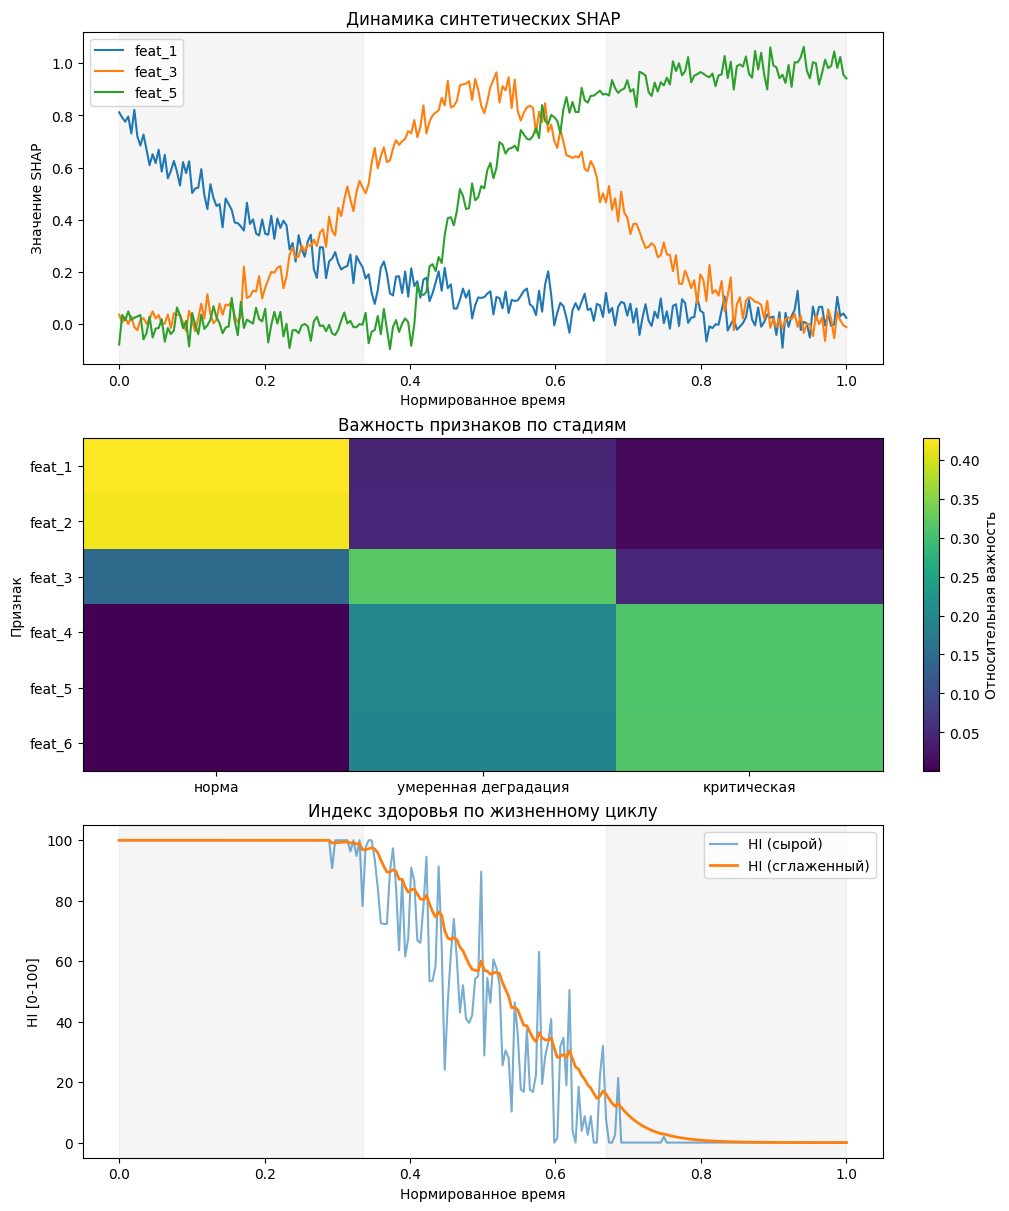

In [4]:
stage_names = ["норма", "умеренная деградация", "критическая"]
k = len(stage_names)
m = 6
feature_names = [f"feat_{i+1}" for i in range(m)]

# Build lifecycle and synthetic SHAP values
[t_vals, stages] = build_lifecycle(num_points=240, stage_breaks=stage_names)
feature_groups = {"early": [0, 1], "mid": [2], "late": [3, 4, 5]}
phi = synthetic_shap_values(t_vals, stages, feature_groups, noise=0.04)
imp = stage_importance(phi, stages, k)

# Synthetic features and normalization
features, trend_types = synthetic_features(t_vals, m)
normalized, mu_base, sigma_base = z_normalize(features, stages, baseline_stage=0)

# HI weights from critical stage importance
stage_idx_for_hi = k - 1
weights = stage_weights(imp, stage_idx_for_hi)
score = compute_score(normalized, trend_types, weights)

# Scale HI to [0, 100] and smooth
healthy_ref = np.percentile(score[stages == 0], 95)
faulty_ref = np.percentile(score[stages == k - 1], 5)
hi_raw = scale_hi(score, healthy_ref, faulty_ref)
hi_smooth = ema_smooth(hi_raw, alpha=0.1)

# Visualize
selected_features = [0, 2, 4]
plot_results(t_vals, stages, phi, imp, hi_raw, hi_smooth, feature_names, stage_names, selected_features)